# 📉 Customer Churn Prediction — Data Science Project

**Goal:** Predict which telecom customers are likely to leave (churn) so the company can act *before* they go.

**Dataset:** Telco Customer Churn (IBM sample data, ~7,000 customers, 20 features)

**Pipeline:** Load → Clean → Explore (EDA) → Preprocess → Model → Evaluate → Interpret → Recommend

---


## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay, accuracy_score, precision_score, recall_score, f1_score)

import warnings
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
RANDOM_STATE = 42
print("Libraries loaded successfully")

Libraries loaded successfully


## Load the Data

The cell below downloads the dataset from IBM's public GitHub repo.
**Backup:** if there's no internet, upload `Telco-Customer-Churn.csv` to Notebook.

In [2]:
import os

URL = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
LOCAL = "Telco-Customer-Churn.csv"

if os.path.exists(LOCAL):
    df = pd.read_csv(LOCAL)
    print("Loaded from local file")
else:
    df = pd.read_csv(URL)
    df.to_csv(LOCAL, index=False)   
    print("Data Downloaded")

print("Shape:", df.shape)
df.head()

Data Downloaded
Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## Data Cleaning

In [5]:
poor = df[pd.to_numeric(df["TotalCharges"], errors="coerce").isnull()]
print("Problem rows:", len(poor))
poor[["customerID", "tenure", "MonthlyCharges", "TotalCharges"]]

Problem rows: 11


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,
753,3115-CZMZD,0,20.25,
936,5709-LVOEQ,0,80.85,
1082,4367-NUYAO,0,25.75,
1340,1371-DWPAZ,0,56.05,
3331,7644-OMVMY,0,19.85,
3826,3213-VVOLG,0,25.35,
4380,2520-SGTTA,0,20.00,
5218,2923-ARZLG,0,19.70,
6670,4075-WKNIU,0,73.35,


These are brand-new customers (`tenure = 0`) whose `TotalCharges` is a blank space. They haven't been billed yet, so it's safe to remove these few rows.

In [6]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df = df.dropna().reset_index(drop=True)

In [7]:
print("Missing values :", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Final shape:", df.shape)

Missing values : 0
Duplicate rows: 0
Final shape: (7032, 21)


In [8]:
# Convert target to 0/1
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

## Exploratory Data Analysis (EDA)

### How imbalanced is the target?

Churn rate: 26.6%  |  Stayed: 73.4%


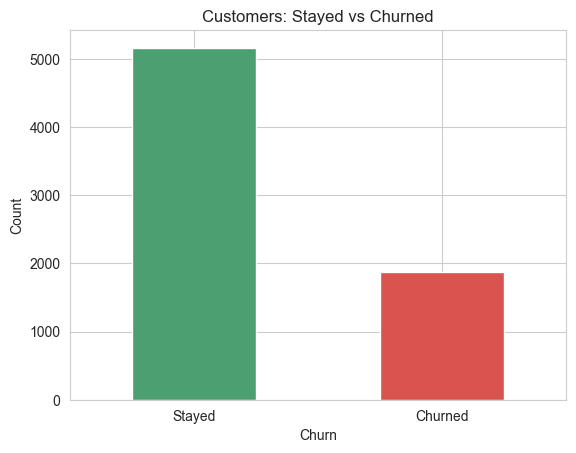

In [9]:
churn_rate = df["Churn"].mean() * 100
print(f"Churn rate: {churn_rate:.1f}%  |  Stayed: {100-churn_rate:.1f}%")

df["Churn"].map({0: "Stayed", 1: "Churned"}).value_counts().plot(
    kind="bar", color=["#4C9F70", "#D9534F"], rot=0)
plt.title("Customers: Stayed vs Churned")
plt.ylabel("Count")
plt.show()

### Contract type vs churn

Contract
Month-to-month    42.7
One year          11.3
Two year           2.8
Name: Churn, dtype: float64


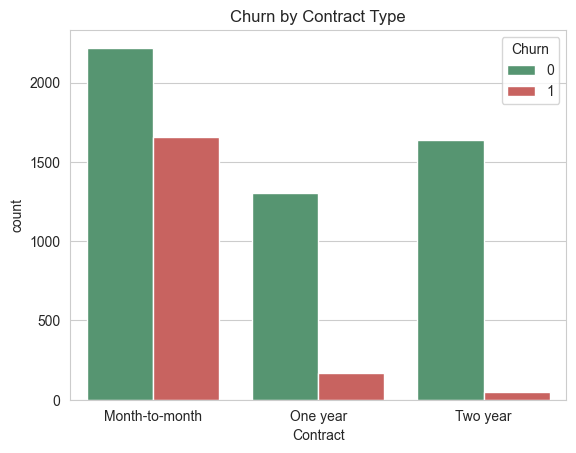

In [10]:
contract_churn = df.groupby("Contract")["Churn"].mean().mul(100).round(1)
print(contract_churn)

sns.countplot(x="Contract", hue="Churn", data=df, palette=["#4C9F70", "#D9534F"])
plt.title("Churn by Contract Type")
plt.show()

### Tenure vs churn

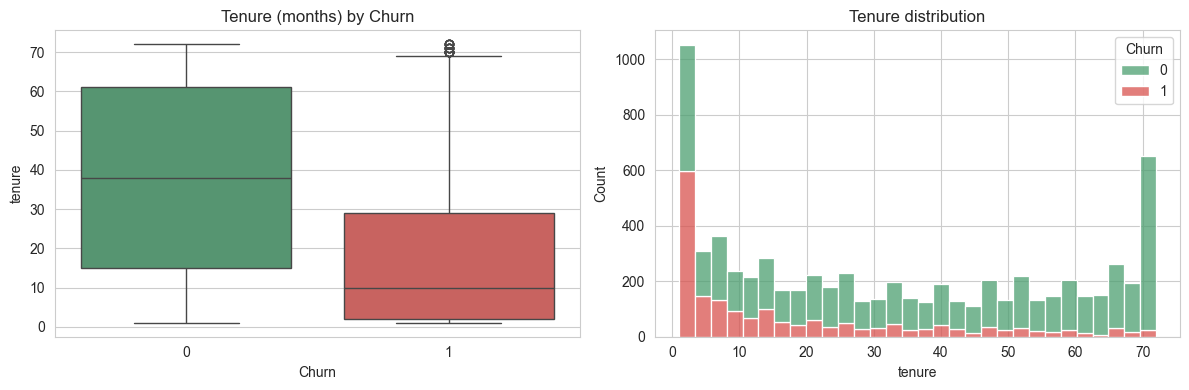

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x="Churn", y="tenure", data=df, palette=["#4C9F70", "#D9534F"], ax=ax[0])
ax[0].set_title("Tenure (months) by Churn")

sns.histplot(data=df, x="tenure", hue="Churn", bins=30, multiple="stack",
             palette=["#4C9F70", "#D9534F"], ax=ax[1])
ax[1].set_title("Tenure distribution")
plt.tight_layout()
plt.show()

### Monthly charges vs churn

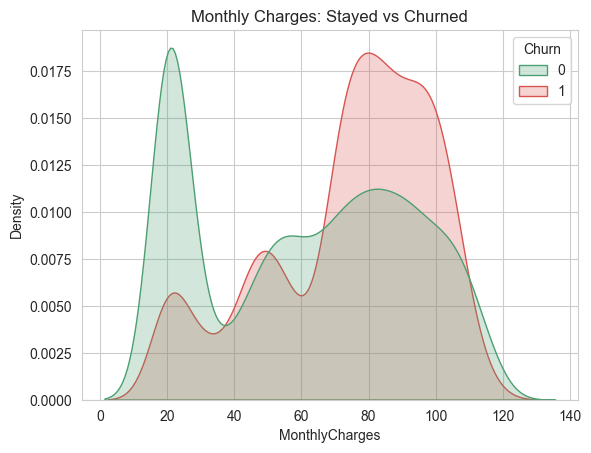

In [12]:
sns.kdeplot(data=df, x="MonthlyCharges", hue="Churn", fill=True,
            palette=["#4C9F70", "#D9534F"], common_norm=False)
plt.title("Monthly Charges: Stayed vs Churned")
plt.show()

### Internet service, payment method, and other categories

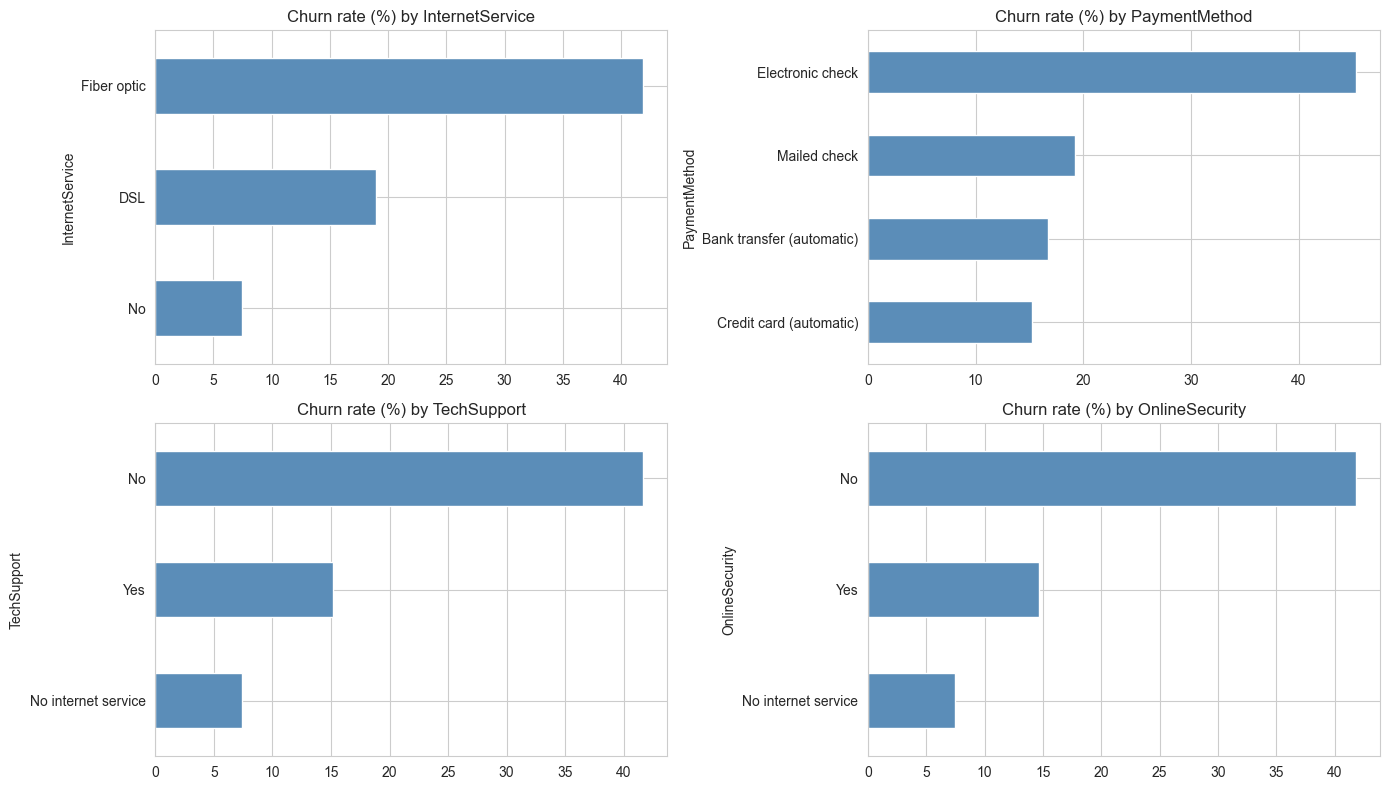

In [13]:
cols = ["InternetService", "PaymentMethod", "TechSupport", "OnlineSecurity"]
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, c in zip(axes.ravel(), cols):
    rate = df.groupby(c)["Churn"].mean().mul(100).sort_values()
    rate.plot(kind="barh", ax=ax, color="#5B8DB8")
    ax.set_title(f"Churn rate (%) by {c}")
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

### Correlation of numeric features

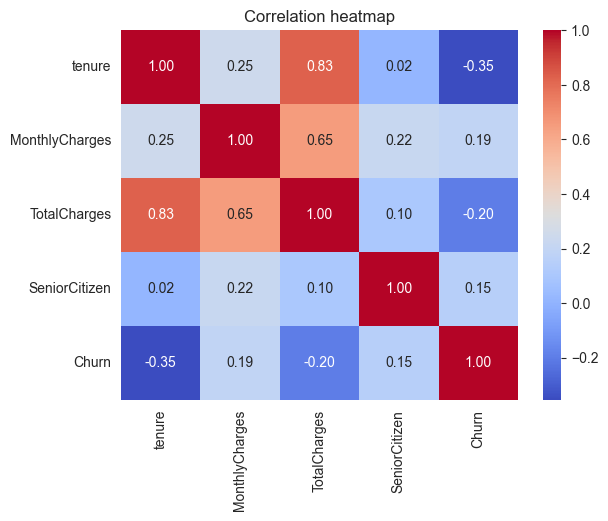

In [14]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen", "Churn"]
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation heatmap")
plt.show()

## Preprocessing

Machine-learning models need numbers. We'll one-hot encode the categorical columns, then split into train and test sets.

In [15]:
target_feature = 'Churn'
numeric_features = ['MonthlyCharges', 'TotalCharges', 'tenure']
categorical_features = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
      'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod']

In [16]:
X = df[numeric_features + categorical_features]
y = df["Churn"]

print("Features after encoding:", X.shape[1])

Features after encoding: 19


In [17]:
from collections import Counter
Counter(y)

Counter({0: 5163, 1: 1869})

Data is imbalanced as Yes and No are not 50-50

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [19]:
print("Train:", X_train.shape, "| Test:", X_test.shape)
print(f"Original data churn rate: {y.mean():.2f}")
print(f"Training data churn rate: {y_train.mean():.2f}")
print(f"Testing data churn rate: {y_test.mean():.2f}")

Train: (5625, 19) | Test: (1407, 19)
Original data churn rate: 0.27
Training data churn rate: 0.27
Testing data churn rate: 0.27


 `stratify=y` keeps the churn proportion the same in both splits. Always do this with imbalanced data.

## Modeling

In [20]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

### Baseline (the model to beat)

In [21]:
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)

,strategy,'most_frequent'
,random_state,None
,constant,None


In [22]:
pred = baseline.predict(X_test)
print("Baseline accuracy:", round(accuracy_score(y_test, pred), 3))
print("Baseline recall (churners found):", recall_score(y_test, pred))

Baseline accuracy: 0.734
Baseline recall (churners found): 0.0


### Logistic Regression (simple, interpretable)

In [23]:
log_reg = Pipeline([
    ("prep", preprocessor),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

In [24]:
log_reg.fit(X_train, y_train)

,steps,"[('prep', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [25]:
print("Logistic Regression trained")

Logistic Regression trained


### Random Forest (more powerful)

In [26]:
rf = Pipeline([("prep", preprocessor),("clf", RandomForestClassifier(n_estimators=300, max_depth=10, min_samples_leaf=5,class_weight="balanced", random_state=42, n_jobs=-1))])

In [27]:
rf.fit(X_train, y_train)

,steps,"[('prep', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [28]:
print("Random Forest trained")

Random Forest trained


## Grid Search

In [29]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

lr_grid = {"clf__C": [0.01, 0.1, 1, 10, 100]}
rf_grid = {
    "clf__n_estimators": [200, 400],
    "clf__max_depth": [6, 10, None],
    "clf__min_samples_leaf": [3, 5, 10],
}

In [30]:
lr_search = GridSearchCV(log_reg, lr_grid, cv=cv, scoring="roc_auc", n_jobs=-1, verbose=1)
lr_search.fit(X_train, y_train)
print("LR  best params:", lr_search.best_params_, "| CV ROC-AUC:", round(lr_search.best_score_, 4))

Fitting 5 folds for each of 5 candidates, totalling 25 fits
LR  best params: {'clf__C': 100} | CV ROC-AUC: 0.8461


In [31]:
rf_search = GridSearchCV(rf, rf_grid, cv=cv, scoring="roc_auc", n_jobs=-1, verbose=1)
rf_search.fit(X_train, y_train)
print("RF  best params:", rf_search.best_params_, "| CV ROC-AUC:", round(rf_search.best_score_, 4))

Fitting 5 folds for each of 18 candidates, totalling 90 fits
RF  best params: {'clf__max_depth': None, 'clf__min_samples_leaf': 10, 'clf__n_estimators': 400} | CV ROC-AUC: 0.8494


In [32]:
log_reg_tuned = lr_search.best_estimator_
rf_tuned = rf_search.best_estimator_

## Evaluation

In [33]:
models = {"Baseline": baseline, "Logistic Regression": log_reg, "Random Forest": rf, "Logistic Regression (Tuned)": log_reg_tuned, "Random Forest (Tuned)": rf_tuned}

rows = []
for name, m in models.items():
    p = m.predict(X_test)
    proba = m.predict_proba(X_test)[:, 1]
    rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, p),
        "Precision": precision_score(y_test, p, zero_division=0),
        "Recall": recall_score(y_test, p),
        "F1": f1_score(y_test, p),
        "ROC-AUC": roc_auc_score(y_test, proba),
    })

results = pd.DataFrame(rows).set_index("Model").round(3)
results

,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Baseline,0.734,0.000,0.000,0.000,0.500
Logistic Regression,0.726,0.490,0.797,0.607,0.835
Random Forest,0.760,0.533,0.767,0.629,0.835
Logistic Regression (Tuned),0.726,0.490,0.799,0.608,0.834
Random Forest (Tuned),0.751,0.521,0.775,0.623,0.837


- **Precision:** of customers we flagged as churners, how many really churned?
- **Recall:** of all real churners, how many did we catch?
- **F1:** balance of precision and recall
- **ROC-AUC:** how well the model ranks churners above non-churners (0.5 = random, 1.0 = perfect)

For churn, **recall usually matters most**: missing a churner costs more than offering a discount to someone who would have stayed.

### Confusion matrices

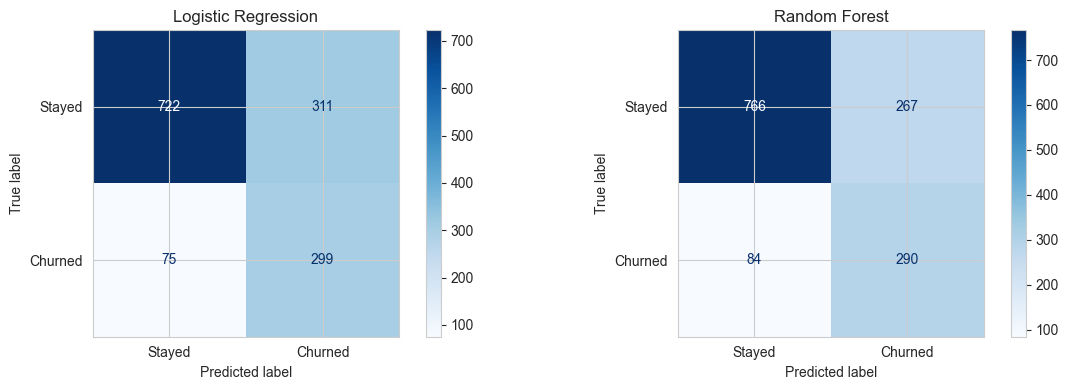

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (name, m) in zip(axes, [("Logistic Regression", log_reg_tuned), ("Random Forest", rf_tuned)]):
    ConfusionMatrixDisplay.from_estimator(
        m, X_test, y_test, display_labels=["Stayed", "Churned"], cmap="Blues", ax=ax)
    ax.set_title(name)
plt.tight_layout()
plt.show()

### Classification report

In [35]:
for name, m in [("Logistic Regression", log_reg_tuned), ("Random Forest", rf_tuned)]:
    print("=" * 50)
    print(name)
    print(classification_report(y_test, m.predict(X_test), target_names=["Stayed", "Churned"]))

Logistic Regression
              precision    recall  f1-score   support

      Stayed       0.91      0.70      0.79      1033
     Churned       0.49      0.80      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.73      0.74      1407

Random Forest
              precision    recall  f1-score   support

      Stayed       0.90      0.74      0.81      1033
     Churned       0.52      0.78      0.62       374

    accuracy                           0.75      1407
   macro avg       0.71      0.76      0.72      1407
weighted avg       0.80      0.75      0.76      1407



### ROC curves

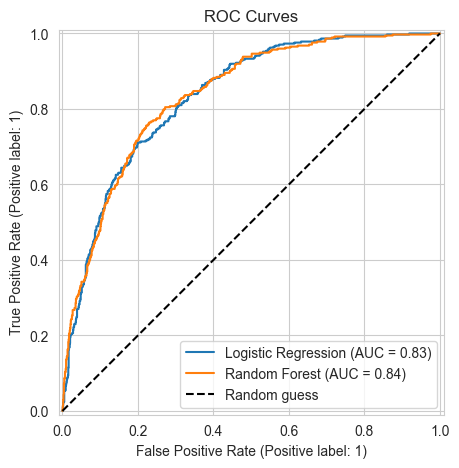

In [36]:
fig, ax = plt.subplots(figsize=(6, 5))
for name, m in [("Logistic Regression", log_reg_tuned), ("Random Forest", rf_tuned)]:
    RocCurveDisplay.from_estimator(m, X_test, y_test, name=name, ax=ax)
ax.plot([0, 1], [0, 1], "k--", label="Random guess")
ax.legend()
ax.set_title("ROC Curves")
plt.show()

### Cross-validation

In [37]:
for name, m in [("Logistic Regression", log_reg_tuned), ("Random Forest", rf_tuned)]:
    scores = cross_val_score(m, X, y, cv=5, scoring="roc_auc")
    print(f"{name}: ROC-AUC = {scores.mean():.3f} (+/- {scores.std():.3f})")

Logistic Regression: ROC-AUC = 0.845 (+/- 0.011)
Random Forest: ROC-AUC = 0.846 (+/- 0.012)


## **Interpretation**

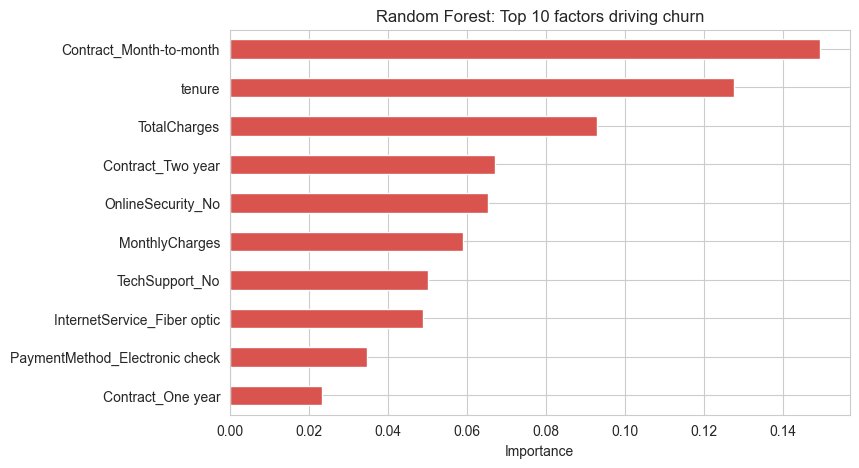

In [38]:
#Random Forest importances
names = rf_tuned.named_steps["prep"].get_feature_names_out()
names = [n.split("__", 1)[1] for n in names]          # drop the "num__"/"cat__" prefix
importances = pd.Series(rf_tuned.named_steps["clf"].feature_importances_, index=names)

importances.nlargest(10).sort_values().plot(kind="barh", color="#D9534F", figsize=(8, 5))
plt.title("Random Forest: Top 10 factors driving churn")
plt.xlabel("Importance")
plt.show()

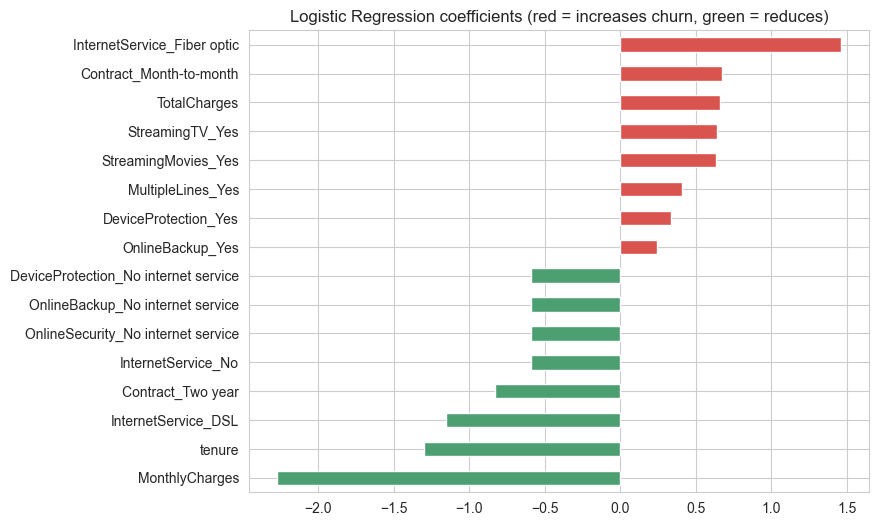

In [39]:
#Logistic Regression coefficients
names = log_reg_tuned.named_steps["prep"].get_feature_names_out()
names = [n.split("__", 1)[1] for n in names]
coefs = pd.Series(log_reg_tuned.named_steps["clf"].coef_[0], index=names)

top = pd.concat([coefs.nsmallest(8), coefs.nlargest(8)]).sort_values()
top.plot(kind="barh", color=["#4C9F70" if v < 0 else "#D9534F" for v in top], figsize=(8, 6))
plt.title("Logistic Regression coefficients (red = increases churn, green = reduces)")
plt.show()

In [40]:
import joblib

joblib.dump(log_reg_tuned, "logistic_model.pkl")
joblib.dump(rf_tuned, "rf_model.pkl")

['rf_model.pkl']

SHAP

In [41]:
import shap
X_train_transformed = rf_tuned.named_steps['prep'].transform(X_train)

In [42]:
feature_names = rf_tuned.named_steps['prep'].get_feature_names_out()

In [43]:
rf_classifier = rf_tuned.named_steps['clf']
explainer = shap.TreeExplainer(rf_classifier)
shap_values = explainer.shap_values(X_train_transformed)

In [44]:
print(type(shap_values))
print(len(shap_values))
print(shap_values[1].shape)
print(X_train_transformed.shape)

<class 'numpy.ndarray'>
5625
(46, 2)
(5625, 46)


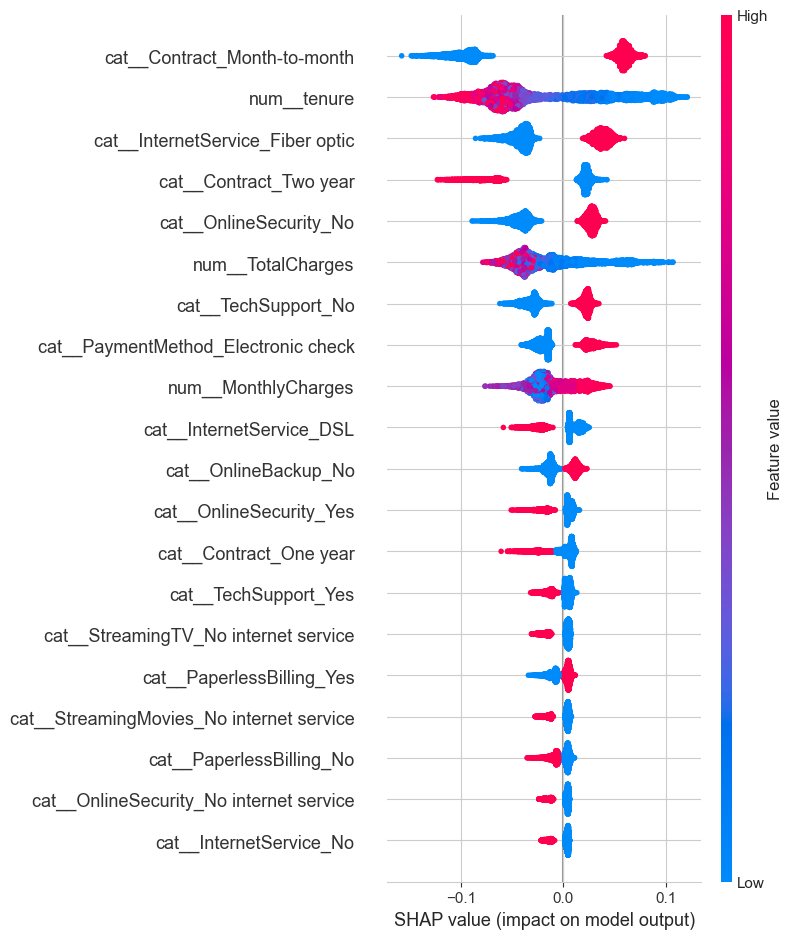

In [45]:
shap.summary_plot(
    shap_values[:, :, 1],
    X_train_transformed,
    feature_names=feature_names
)

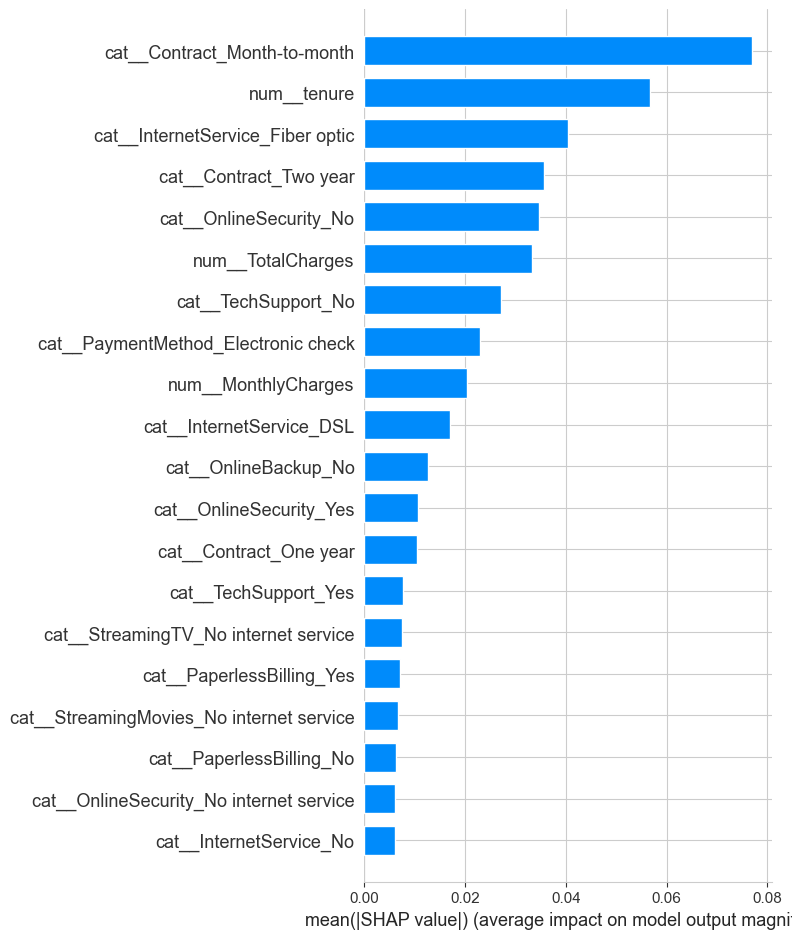

In [46]:
shap.summary_plot(
    shap_values[:, :, 1],
    X_train_transformed,
    feature_names=feature_names,
    plot_type="bar"
)

## **Putting the Model to Work**

Identify the highest-risk customers

In [47]:
risk = X_test.copy()
risk["churn_probability"] = rf.predict_proba(X_test)[:, 1]
risk["actually_churned"] = y_test.values

top20 = risk.sort_values("churn_probability", ascending=False).head(20)
print(f"Of the 20 highest-risk customers, {top20['actually_churned'].sum()} really churned.")
top20[["tenure", "MonthlyCharges", "churn_probability", "actually_churned"]].round(2)

Of the 20 highest-risk customers, 18 really churned.


,tenure,MonthlyCharges,churn_probability,actually_churned
3154,3,94.85,0.95,0
3374,1,95.10,0.94,1
2792,3,100.95,0.94,1
3721,3,96.60,0.94,1
2626,7,99.25,0.94,1
4577,1,85.05,0.94,1
2748,1,95.65,0.93,1
2459,1,77.15,0.92,1
2392,1,88.35,0.92,1
2724,2,85.70,0.92,1


### Predict for a single new customer

In [48]:
# Take one customer from the test set and see the prediction
sample = X_test.iloc[[0]]
prob = rf.predict_proba(sample)[0, 1]
print(f"Churn probability: {prob:.1%}")
print("Prediction:", "⚠️ Likely to churn" if prob >= 0.5 else "✅ Likely to stay")
print("Actual outcome:", "Churned" if y_test.iloc[0] == 1 else "Stayed")

Churn probability: 1.8%
Prediction: ✅ Likely to stay
Actual outcome: Stayed


### Choosing a decision threshold

In [49]:
proba = rf.predict_proba(X_test)[:, 1]
rows = []
for t in [0.3, 0.4, 0.5, 0.6, 0.7]:
    p = (proba >= t).astype(int)
    rows.append({"Threshold": t,
                 "Precision": precision_score(y_test, p),
                 "Recall": recall_score(y_test, p),
                 "Customers flagged": int(p.sum())})
pd.DataFrame(rows).round(3)

,Threshold,Precision,Recall,Customers flagged
0,0.3,0.432,0.877,760
1,0.4,0.482,0.834,647
2,0.5,0.533,0.767,538
3,0.6,0.586,0.639,408
4,0.7,0.653,0.508,291


Lowering the threshold catches more churners (higher recall) but flags more customers (lower precision). The business must choose based on the **cost of a retention offer vs. the cost of losing a customer**.

## Business Recommendations

| Finding | Recommended action |
|---|---|
| Month-to-month contracts churn most | Offer discounts or perks to switch to annual plans |
| New customers churn early | Run an onboarding / first-90-days support program |
| High monthly charges increase churn | Review pricing; offer bundles or loyalty discounts |
| No tech support or security → more churn | Bundle these services free for a trial period |
| Electronic check payers churn more | Encourage automatic payment with a small incentive |
| Model ranks customers by risk | Target retention calls and offers at the top-risk group |

## Conclusion

- We built and compared a baseline, Logistic Regression, and Random Forest.
- Accuracy alone is misleading on imbalanced data, so we used recall, precision, F1, and ROC-AUC.
- The model identifies at-risk customers and explains *why* they are at risk, which makes it actionable.

